# Charge neutrality: fixing nfuel, solving for ne
Add charge neutrality as second equation. Fix n_fuel, then solve for n_e.

In [1]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
from IPython.display import clear_output
from process.main import SingleRun
import process.data_structure
import process.impurity_radiation as impurity_radiation
import process.constraints
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors
import process.physics
import pandas as pd
import seaborn as sns
from process.io.plot_solutions import (
    RunMetadata,
    plot_mfile_solutions,
    plot_mfile_solutions_constraints,
)
from pathlib import Path

Running scipy's SLSQP


Running without any radiation modifications solves: replicate for now.

In [2]:
# Set up
INPUT_FILE = "data/lt_solve_IN.DAT"
single_run = SingleRun(INPUT_FILE)
process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[13] = (
    5.0e-6
)
# process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 800.0
# impurity_radiation.rho_fix = True
# process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
# impurity_radiation.int_edge_rad = True
# process.data_structure.physics_variables.i_rad_loss = 0
# process.physics.old_n_alpha_calc = False
# Current n_alpha calc
process.physics.current_n_alpha_calc = True
# process.physics.mattis_test = False
# process.physics.eval_count = 0

ne = 9.0e19
te = 10.0
process.data_structure.physics_variables.dene = ne
process.data_structure.physics_variables.te = te
# process.data_structure.physics_variables.znfuel = 5.0e20

single_run.run()
clear_output()
print(f"{single_run.scan.ifail = }")

single_run.scan.ifail = 1


In [3]:
ne_sol = process.data_structure.physics_variables.dene
te_sol = process.data_structure.physics_variables.te
print(f"ne = {ne_sol:.3e}")
print(f"te = {te_sol:.3e}")

ne = 9.684e+19
te = 1.168e+01


This solution appears reasonable.

## Visualising constraints
Evaluate constraints.

In [4]:
# Common process set up
input_file = "data/lt_eval_IN.DAT"
single_run = SingleRun(input_file)
process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[13] = (
    5.0e-6
)
# impurity_radiation.rho_fix = True
# impurity_radiation.int_edge_rad = True
# process.physics.old_n_alpha_calc = False
# process.physics.current_n_alpha_calc = True
# process.physics.mattis_test = False

# Study set up
N = 7
ne = np.linspace(7.0e19, 1.1e20, num=N)
te = np.linspace(8.0, 14.0, num=N)
ne_grid, te_grid = np.meshgrid(ne, te)


# Evaluation func
def eval_n_alpha(ne, te):
    single_run = SingleRun(input_file)
    # Loading single run overwrites variables: set again
    # process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 300.0
    # process.data_structure.physics_variables.hfact = 1.0
    # process.data_structure.physics_variables.i_rad_loss = 1
    # process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0

    process.data_structure.physics_variables.dene = ne
    process.data_structure.physics_variables.te = te
    # process.physics.eval_count = 0
    # Bad idea, but try to get to solve
    # process.data_structure.constraint_variables.f_alpha_energy_confinement_min = 5.0

    try:
        # Handle failed runs
        single_run.run()
    except Exception as e:
        return np.nan, np.nan, e

    return (
        process.constraints.constraint_equation_2().normalised_residual,
        process.constraints.constraint_equation_93().normalised_residual,
        None,
    )


def make_df(con2, con93, e):
    return pd.DataFrame(
        {
            "ne": ne_grid.flatten(),
            "te": te_grid.flatten(),
            "ppb_con": con2.flatten(),
            "charge_neut_con": con93.flatten(),
            "error": e.flatten(),
        }
    )


eval_n_alpha_vec = np.vectorize(pyfunc=eval_n_alpha)
clear_output()


In [5]:
con2, con93, e = eval_n_alpha_vec(ne_grid, te_grid)
clear_output()
make_df(con2, con93, e)

,ne,te,ppb_con,charge_neut_con,error
0,7.000000e+19,8.0,0.180949,0.201423,None
1,7.666667e+19,8.0,0.147683,0.137410,None
2,8.333333e+19,8.0,0.110461,0.077426,None
3,9.000000e+19,8.0,0.070187,0.023370,None
4,9.666667e+19,8.0,0.028151,-0.020869,None
5,1.033333e+20,8.0,-0.013365,-0.045455,None
6,1.100000e+20,8.0,-0.048674,-0.008625,None
7,7.000000e+19,9.0,0.163063,0.210996,None
8,7.666667e+19,9.0,0.137808,0.148040,None
9,8.333333e+19,9.0,0.108921,0.088309,None


Text(0.5, 0.98, 'Constraint evaluations')

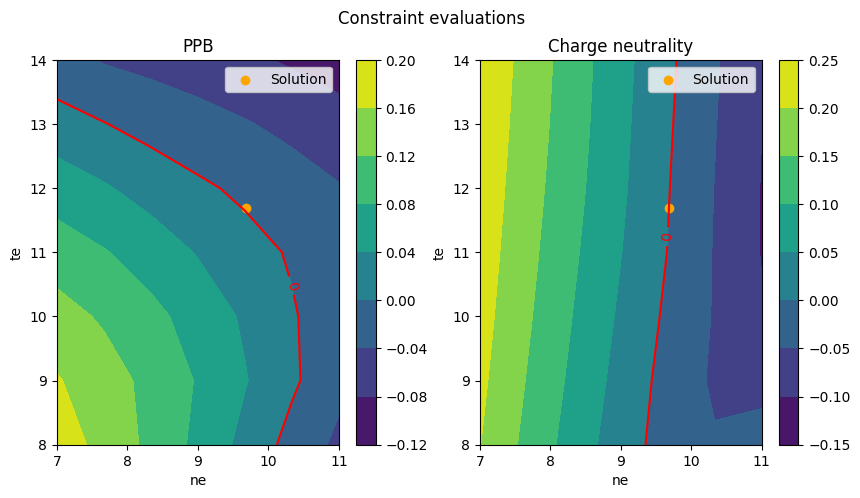

In [6]:
%matplotlib inline
fig, axs = plt.subplots(ncols=2)
fig.set_size_inches(10, 5)
contour = axs[0].contourf(
    (ne_grid * 1e-19),
    te_grid,
    con2,
)
fig.colorbar(contour, ax=axs[0])
axs[0].set_xlabel("ne")
axs[0].set_ylabel("te")
cs = axs[0].contour(
    (ne_grid * 1e-19),
    te_grid,
    con2,
    levels=[0.0],
    colors="red",
)
axs[0].clabel(cs)
axs[0].scatter(ne_sol * 1e-19, te_sol, c="orange", label="Solution")
axs[0].legend()

# Second plot
contour = axs[1].contourf(
    (ne_grid * 1e-19),
    te_grid,
    con93,
)
fig.colorbar(contour, ax=axs[1])
axs[1].set_xlabel("ne")
axs[1].set_ylabel("te")
cs = axs[1].contour(
    (ne_grid * 1e-19),
    te_grid,
    con93,
    levels=[0.0],
    colors="red",
)
axs[1].clabel(cs)
axs[1].scatter(ne_sol * 1e-19, te_sol, c="orange", label="Solution")
axs[1].legend()
axs[0].set_title("PPB")
axs[1].set_title("Charge neutrality")
fig.suptitle("Constraint evaluations")

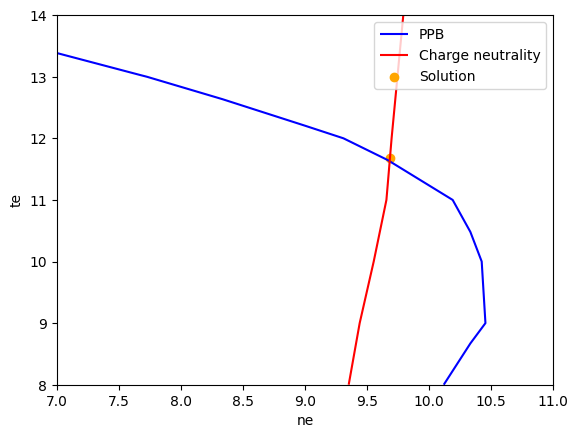

In [18]:
%matplotlib inline
fig, ax = plt.subplots()
# fig.set_size_inches(10, 5)
ax.set_xlabel("ne")
ax.set_ylabel("te")
cs1 = ax.contour((ne_grid * 1e-19), te_grid, con2, levels=[0.0], colors="blue")
cs2 = ax.contour(
    (ne_grid * 1e-19),
    te_grid,
    con93,
    levels=[0.0],
    colors="red",
)
name1, label1 = cs1.legend_elements()
name2, label2 = cs2.legend_elements()
scatter = ax.scatter(ne_sol * 1e-19, te_sol, c="orange", label="Solution")
name3, label3 = ax.get_legend_handles_labels()
ax.legend(name1 + name2 + name3, ["PPB", "Charge neutrality", "Solution"])